# 0. importacion de librerias y funciones de utils

In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

from src.utils import DEFAULT_TRAIN, add_features, clean_trips

%load_ext autoreload
%autoreload 2
plt.style.use("seaborn-v0_8-whitegrid")

raw = pd.read_csv(DEFAULT_TRAIN, parse_dates=["pickup_datetime"])
universe = clean_trips(add_features(raw))

# variables del modelo (ya justificadas: log-transform + codificación cíclica)
universe["log_distance"] = np.log(universe["distance_km"])
universe["log_duration"] = np.log(universe["trip_duration"])
universe["hour_sin"] = np.sin(2 * np.pi * universe["hour"] / 24)
universe["hour_cos"] = np.cos(2 * np.pi * universe["hour"] / 24)

FEATURES = ["log_distance", "log_duration", "hour_sin", "hour_cos"]

N_SAMPLE = 40_000
SEED = 42
df = universe.sample(n=N_SAMPLE, random_state=SEED).reset_index(drop=True)
print("Muestra:", df.shape)

inside NYC bounding box             removed    633  (left 1458011)
duration between 1 min and 3 h      removed  10595  (left 1447416)
distance >= 0.1 km                  removed   7463  (left 1439953)
speed between 1 and 100 km/h        removed   1342  (left 1438611)
Total kept: 1438611/1458644 (98.6%)
Muestra: (40000, 20)


# 1. EDA mínimo para el modelo GMM

**Objetivo.** Verificar que las 4 variables elegidas (`log_distance`, `log_duration`, `hour_sin`, `hour_cos`) tienen una forma adecuada para un modelo de mezcla de gaussianas, y detectar visualmente si parece haber más de un grupo (evidencia visual de la necesidad de un modelo de mezcla).

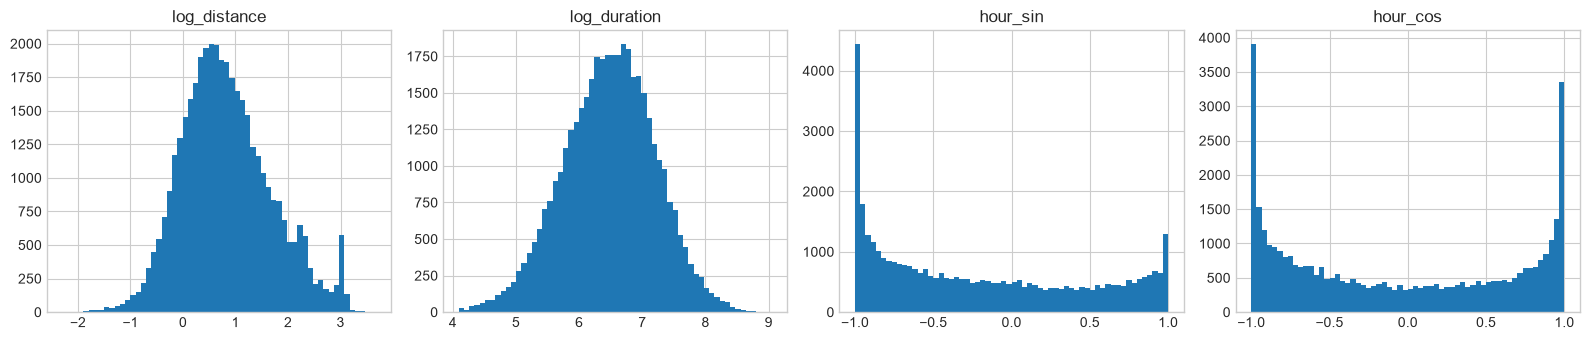

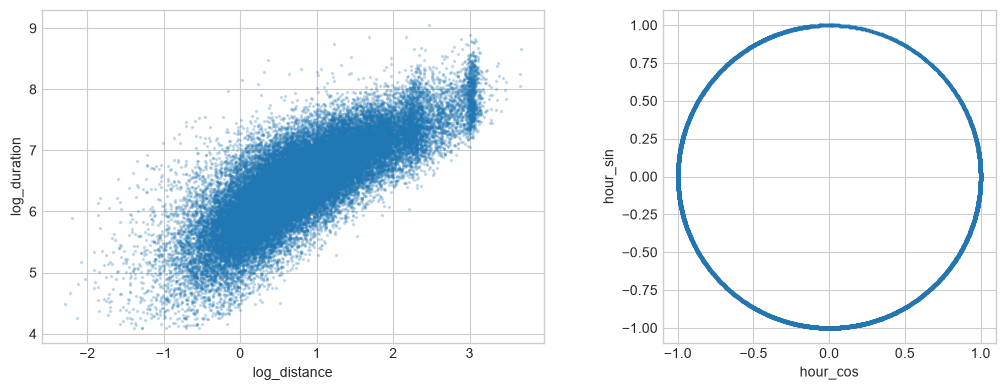

In [2]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
for ax, col in zip(axes, FEATURES):
    ax.hist(df[col], bins=60)
    ax.set_title(col)
plt.tight_layout()
plt.show()

# vista 2D: ¿se insinúan grupos?
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(df["log_distance"], df["log_duration"], s=2, alpha=0.2)
axes[0].set_xlabel("log_distance"); axes[0].set_ylabel("log_duration")

axes[1].scatter(df["hour_cos"], df["hour_sin"], s=2, alpha=0.2)
axes[1].set_xlabel("hour_cos"); axes[1].set_ylabel("hour_sin")
axes[1].set_aspect("equal")
plt.tight_layout()
plt.show()

## Interpretación del EDA de las variables del modelo

**1. `log_distance` y `log_duration` — de asimetría a forma gaussiana**

Las variables originales (`distance_km`, `trip_duration`) tienen una distribución *asimétrica a la derecha*: la mayoría de los viajes son cortos, pero existen pocos viajes muy largos que generan una cola extendida. Esta forma no se ajusta al supuesto del GMM, que asume que cada grupo latente sigue una distribución gaussiana (forma de campana).

Al aplicar logaritmo, los valores grandes se comprimen mucho más que los pequeños ($\log(50) - \log(20) < \log(2) - \log(1)$), lo que corrige la asimetría y produce una distribución mucho más cercana a una campana. **Por qué nos importa:** un modelo ajustado sobre variables que sí cumplen el supuesto gaussiano estima centros ($\mu_k$) y covarianzas ($\Sigma_k$) más confiables; sobre variables muy asimétricas, el modelo distorsiona la forma de los grupos para intentar cubrir la cola.

**2. `hour_sin` y `hour_cos` — proyecciones de un círculo**

Por separado, cada una muestra una forma de "U" o arco (más densidad cerca de los extremos −1 y +1, menos cerca de 0), porque son la proyección horizontal (coseno) y vertical (seno) de un punto que recorre un círculo de 24 horas. Al graficarlas juntas (`hour_cos` vs. `hour_sin`), se observa el círculo completo: cada punto representa una hora del día, codificada de forma que las 23:00 y las 00:00 queden geométricamente cerca, en vez de en extremos opuestos.

**Por qué nos importa:** esta transformación evita que el modelo trate horas cercanas en el reloj (23:00 y 00:00) como si fueran opuestas. Sin embargo, introduce una tensión con el supuesto gaussiano: los puntos viven sobre un anillo, no forman una nube "rellena". En la práctica, el GMM aproxima este anillo con **varias componentes elípticas** distribuidas a lo largo del círculo, en vez de una sola campana global — una limitación que vale la pena mencionar explícitamente al interpretar los perfiles finales.

**3. Qué buscamos en conjunto**

Este EDA no es decorativo: su propósito es verificar, *antes* de ajustar el modelo, que las variables elegidas tienen una forma razonable para el supuesto gaussiano, y detectar de forma visual si los datos ya insinúan la existencia de varios grupos mezclados — la motivación misma de usar un modelo de mezcla en lugar de una sola distribución.